# Reconhecimento de Padr?es - EDA


## Obten??o dos dados


In [1]:
# CÓDIGO ORIGINAL FORNECIDO:

from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# metadata
print(adult.metadata)

# variable information
print(adult.variables)


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [3]:
# =================================================================
# INFORMAÇÕES GERAIS, VISUALIZAÇÃO E CARACTERÍSTICAS
# =================================================================

# 1. Juntar as features (X) e targets (y) num único DataFrame
df = pd.concat([X, y], axis=1)

# Pegando a quantidade de linhas e colunas
linhas = df.shape[0]
colunas = df.shape[1]

print(f"O dataset possui {linhas} linhas e {colunas} colunas.\n")

# 2. Features (variáveis independentes)
features = X.columns.tolist()
qtd_features = len(features)


print(f"\n São {qtd_features} features:")
for feature in features:
    print(f"- {feature}")

# 3. Listando o Target (variável dependente / classe alvo)
targets = y.columns.tolist()

print(f"\nTarget (variável dependente):")
for target in targets:
    print(f"- {target}")

print("\n--- Sample tabela ---")
display(df.head())

O dataset possui 48842 linhas e 15 colunas.


 São 14 features:
- age
- workclass
- fnlwgt
- education
- education-num
- marital-status
- occupation
- relationship
- race
- sex
- capital-gain
- capital-loss
- hours-per-week
- native-country

Target (variável dependente):
- income

--- Sample tabela ---


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Dataset escolhido: https://archive.ics.uci.edu/dataset/2/adult

In [2]:
# Importações necessárias / bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Limpeza dos dados


In [5]:
print("--- Existem outliers e missing values ---")

# Calcula o n?mero de inst?ncias com missing values
num_instances_with_missing = df.isnull().any(axis=1).sum()
print(f"N?mero de inst?ncias com missing values em qualquer posi??o: {num_instances_with_missing}
")

# Missing values por coluna
missing_por_coluna = df.isnull().sum().sort_values(ascending=False)
print("Missing values por coluna:")
print(missing_por_coluna)

# Analisar dados n?o num?ricos: qual valor e qual frequ?ncia?
# A biblioteca ucimlrepo j? remove alguns outliers e transforma em NaN
colunas_texto = df.select_dtypes(include=['object']).columns

for coluna in colunas_texto:
    print(f"
Feature: '{coluna}'")
    # dropna=False mostra valores nulos por default (NaN)
    print(df[coluna].value_counts(dropna=False))
    print("-" * 40)  # divisor visual



--- Existem Outliers e missing values ---
Número de instâncias com missing values em qualquer posição: 1221


Feature: 'workclass'
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
NaN                   963
Without-pay            21
Never-worked           10
Name: count, dtype: int64
----------------------------------------

Feature: 'education'
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64
----------------------------------------

Feature: 'marital-status'
marital-status
Married-civ-spouse       22379
Never-m

C:\Users\vinic\AppData\Local\Temp\ipykernel_18936\2696747336.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = df.select_dtypes(include=['object']).columns


In [ ]:
# Remo??o de linhas com missing values
before = len(df)
df = df.dropna()
after = len(df)
print(f"Linhas removidas por missing values: {before - after}")
print(f"Linhas restantes: {after}")


In [ ]:
# Verifica??o de linhas duplicadas (id?nticas)
num_dups = df.duplicated().sum()
print(f"N?mero de linhas duplicadas: {num_dups}")


In [ ]:
# Remo??o de linhas duplicadas
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Linhas removidas por duplicidade: {before - after}")
print(f"Linhas restantes: {after}")


## EDA (pr?-Feature Engineering)


In [4]:
print("--- 1. TIPOS DE DADOS DAS FEATURES ---")
tipos_dados = df.dtypes.value_counts()
print(tipos_dados)

--- 1. TIPOS DE DADOS DAS FEATURES ---
str      9
int64    6
Name: count, dtype: int64


In [ ]:
# O que falta:
# Resumo sobre missing values
# Heatmap / matriz de correlação
# boxplot - tem outliers? como é a distribuição?


In [ ]:
# =================================================================
# WIP MATRIX DE CORRELAÇÃO (HEATMAP)
# =================================================================


In [22]:
# Valores únicos em colunas categóricas selecionadas
for col in ['native-country', 'occupation', 'workclass']:
    print(f"{col}: {df[col].nunique()} valores únicos")


native-country: 42 valores ?nicos
occupation: 15 valores ?nicos
workclass: 9 valores ?nicos


In [ ]:
# Distribui??o (histograma) de workclass
plt.figure(figsize=(10, 4))
sns.histplot(data=df, y='workclass')
plt.title('Distribui??o de workclass')
plt.xlabel('Frequ?ncia')
plt.ylabel('workclass')
plt.tight_layout()
plt.show()

# Distribui??o (histograma) de occupation
plt.figure(figsize=(10, 4))
sns.histplot(data=df, y='occupation')
plt.title('Distribui??o de occupation')
plt.xlabel('Frequ?ncia')
plt.ylabel('occupation')
plt.tight_layout()
plt.show()


## Feature Engineering


**Significado de algumas categorias da coluna `education`**

- `Assoc-acdm`: curso de *Associate* de natureza acad?mica (equivalente a um tecn?logo/curso superior curto, tipicamente 2 anos).
- `Assoc-voc`: curso de *Associate* de natureza vocacional/t?cnica (forma??o mais voltada ao mercado de trabalho).
- `10th`: 10? ano do ensino m?dio (high school) nos EUA.
- `11th`: 11? ano do ensino m?dio (high school) nos EUA.
- `12th`: 12? ano do ensino m?dio (high school) nos EUA, geralmente o ?ltimo ano antes da gradua??o.


In [ ]:
# Agrupamento de n?veis de educa??o
edu_map = {
    'Preschool': 'dropout',
    '1st-4th': 'dropout',
    '5th-6th': 'dropout',
    '7th-8th': 'dropout',
    '9th': 'dropout',
    '10th': 'dropout',
    '11th': 'dropout',
    '12th': 'dropout',
    'HS-Grad': 'HighGrad',
    'HS-grad': 'HighGrad',
    'Some-college': 'CommunityCollege',
    'Assoc-acdm': 'CommunityCollege',
    'Assoc-voc': 'CommunityCollege',
    'Bachelors': 'Bachelors',
    'Masters': 'Masters',
    'Prof-school': 'Masters',
    'Doctorate': 'Doctorate',
}
df['education'] = df['education'].replace(edu_map)

# M?dia de education-num por categoria ap?s o agrupamento
(df[['education', 'education-num']]
    .groupby(['education'], as_index=False)
    .mean()
    .sort_values(by='education-num', ascending=False))


In [21]:
# Drop de fnlwgt
df = df.drop(columns=['fnlwgt'])
print('fnlwgt presente:', 'fnlwgt' in df.columns)


fnlwgt presente: False


In [23]:
# Label encoding para sex
df['sex'] = pd.Categorical(df['sex']).codes
print('sex codificado (exemplo):')
print(df['sex'].value_counts().sort_index())


sex codificado (exemplo):


sex
0    16192
1    32650
Name: count, dtype: int64


In [ ]:
# Discretiza??o de age em faixas (0-18 fixo, demais por quantis)
age = df['age']
mask_adult = age > 18

# Quantis para distribuir uniformemente as idades adultas
n_bins = 8
age_bin = pd.Series(index=df.index, dtype='object')
age_bin.loc[mask_adult] = pd.qcut(age[mask_adult], q=n_bins, duplicates='drop').astype(str)
age_bin.loc[~mask_adult] = '0-18'
df['age_bin'] = age_bin.astype('category')
print(df['age_bin'].value_counts().sort_index())


In [ ]:
# Agrupamento de marital-status
marital_map = {
    'Never-married': 'NotMarried',
    'Married-AF-spouse': 'Married',
    'Married-civ-spouse': 'Married',
    'Married-spouse-absent': 'NotMarried',
    'Separated': 'Separated',
    'Divorced': 'Separated',
    'Widowed': 'Widowed',
}
df['marital-status'] = df['marital-status'].replace(marital_map)


**Categorias de marital-status**

- `Married-AF-spouse`: casado com c?njuge nas For?as Armadas dos EUA (AF = Armed Forces).
- `Married-civ-spouse`: casado com c?njuge civil (n?o militar).
- `Married-spouse-absent`: casado(a), mas o c?njuge est? ausente (por separa??o de fato, trabalho, etc.).


In [ ]:
# Discretiza??o estatisticamente uniforme de hours-per-week (quantis)
# 5 grupos ? um n?mero razo?vel e mant?m interpretabilidade
n_bins = 5
df['hours-per-week-bin'] = pd.qcut(df['hours-per-week'], q=n_bins, duplicates='drop')
print('Bins de hours-per-week:', df['hours-per-week-bin'].cat.categories)


In [ ]:
# Snapshot do dataframe categ?rico antes do one-hot
df_cat = df.copy()


In [ ]:
# Feature: capital-balance (capital-gain - capital-loss)
if 'capital-balance' not in df.columns:
    if 'capital-gain' in df.columns and 'capital-loss' in df.columns:
        df['capital-balance'] = df['capital-gain'] - df['capital-loss']
    else:
        raise KeyError('capital-gain/capital-loss ausentes para criar capital-balance')


In [25]:
# One-Hot Encoding para marital-status, relationship, race, native-country, occupation, workclass e age_bin
ohe_cols = ['marital-status', 'relationship', 'race', 'native-country', 'occupation', 'workclass', 'age_bin']
df = pd.get_dummies(df, columns=ohe_cols, prefix=ohe_cols, drop_first=False)
print('One-hot aplicado em:', ohe_cols)
print('Colunas atuais:', len(df.columns))


One-hot aplicado em: ['marital-status', 'relationship', 'race']
Colunas atuais: 27


In [8]:
# Preparação da target
target_col = y.columns[0]
df[target_col] = df[target_col].astype(str).str.strip().str.replace('.', '', regex=False)
vals = sorted(df[target_col].dropna().unique())
print('Valores da target:', vals)

if '>50K' in vals:
    target_positive = '>50K'
elif '1' in vals:
    target_positive = '1'
else:
    target_positive = vals[-1]

df['_target_bin'] = (df[target_col] == target_positive).astype(int)
df = df.drop(columns=[target_col])

print('Target positiva:', target_positive)
print(df['_target_bin'].value_counts())


Valores da target: ['<=50K', '>50K']
Target positiva: >50K
_target_bin
0    37155
1    11687
Name: count, dtype: int64


In [28]:
# Amostra do dataframe após o feature engineering
# Garante a target binária como última coluna
cols = [c for c in df.columns if c != '_target_bin'] + ['_target_bin']
df = df[cols]

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 0)

# Exibe com scroll horizontal
display(df.head().style.set_table_attributes('style="display:block; overflow-x:auto; white-space:nowrap;"'))


,workclass,education-num,occupation,sex,hours-per-week,native-country,_target_bin,capital-balance,age_bin,marital-status_Divorced,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,State-gov,13,Adm-clerical,1,40,United-States,0,2174,36-45,False,...,True,False,False,False,False,False,False,False,False,True
1,Self-emp-not-inc,13,Exec-managerial,1,13,United-States,0,0,46-55,False,...,False,False,False,False,False,False,False,False,False,True
2,Private,9,Handlers-cleaners,1,40,United-States,0,0,36-45,True,...,True,False,False,False,False,False,False,False,False,True
3,Private,7,Handlers-cleaners,1,40,United-States,0,0,46-55,False,...,False,False,False,False,False,False,False,True,False,False
4,Private,13,Prof-specialty,0,40,Cuba,0,0,26-35,False,...,False,False,False,False,True,False,False,True,False,False


## Reparos

Checklist de colunas esperadas antes de rodar EDA/FE.


In [ ]:
# Diagn?stico r?pido de colunas esperadas
expected_cols = ["age", "hours-per-week", "marital-status", "relationship", "race", "sex", "workclass", "occupation", "native-country", "_target_bin"]
missing = [c for c in expected_cols if c not in df.columns]
print('Colunas ausentes:', missing)

# Se alguma estiver ausente, rode a c?lula correspondente antes


## EDA (p?s-Feature Engineering)


In [ ]:
# Helpers para correlação e distribuição por classe
from scipy.stats import chi2_contingency, pointbiserialr

sns.set_theme(style='whitegrid')

def cramers_v(col_a, col_b):
    ct = pd.crosstab(col_a, col_b)
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    v = np.sqrt(phi2corr / max(1, min((kcorr - 1), (rcorr - 1))))
    return v, p, ct

def hist_by_class_num(col, bins=30, cap_upper=None, data=None):
    data = df if data is None else data
    data = data[[col, "_target_bin"]].copy()
    if cap_upper is not None:
        data[col] = data[col].clip(upper=cap_upper)

    plt.figure(figsize=(8, 4))
    sns.histplot(data=data, x=col, hue="_target_bin", bins=bins, kde=False, stat="count", common_norm=False)
    if cap_upper is not None:
        plt.axvline(cap_upper, color="gray", linestyle="--", linewidth=1)
    plt.title(f"Distribui??o de {col} por classe da target")
    plt.xlabel(col)
    plt.ylabel("Frequ?ncia")
    plt.tight_layout()
    plt.show()

def plot_dist_by_class(col, title, bins=30, cap_upper=None, data=None):
    data = df if data is None else data
    if "_target_bin" not in data.columns:
        data = data.copy()
        data["_target_bin"] = df["_target_bin"].values
    data = data[[col, "_target_bin"]].copy()
    if cap_upper is not None:
        data[col] = data[col].clip(upper=cap_upper)

    plt.figure(figsize=(8, 4))
    if pd.api.types.is_numeric_dtype(data[col]):
        sns.histplot(data=data, x=col, hue='_target_bin', bins=bins, kde=False, stat='count', common_norm=False)
        if cap_upper is not None:
            plt.axvline(cap_upper, color='gray', linestyle='--', linewidth=1)
            plt.title(f"{title} (>= {cap_upper} agrupado em {cap_upper}+")
            ax = plt.gca()
            ticks = sorted(set(list(ax.get_xticks()) + [cap_upper]))
            labels = [str(int(t)) if t != cap_upper else f"{int(cap_upper)}+" for t in ticks]
            ax.set_xticks(ticks)
            ax.set_xticklabels(labels)
        else:
            plt.title(title)
    else:
        sns.countplot(data=data, x=col, hue='_target_bin')
        plt.title(title)
        plt.xticks(rotation=45, ha='right')

    plt.xlabel(col)
    plt.ylabel('Frequência')
    plt.tight_layout()
    plt.show()


In [ ]:
# Associação entre marital-status e relationship (Cramér's V)
v, p, ct = cramers_v(df_cat['marital-status'], df_cat['relationship'])
print(f"Cramér's V: {v:.3f} | p-value: {p:.4g}")
print('Contingência (linhas x colunas):', ct.shape)


In [ ]:
# Impacto de marital-status na target (distribuição por classe)
plot_dist_by_class('marital-status', 'Distribuição de marital-status por classe da target', data=df_cat)


In [ ]:
# Impacto de relationship na target (distribuição por classe)
plot_dist_by_class('relationship', 'Distribuição de relationship por classe da target', data=df_cat)


In [ ]:
# Impacto de race na target (Cramér's V + distribuição por classe)
v, p, _ = cramers_v(df_cat['race'], df['_target_bin'])
print(f"Cramér's V: {v:.3f} | p-value: {p:.4g}")
plot_dist_by_class('race', 'Distribui??o de race por classe da target', data=df_cat)


In [ ]:
# Impacto de sex na target (Cramér's V + distribuição por classe)
v, p, _ = cramers_v(df_cat['sex'], df['_target_bin'])
print(f"Cramér's V: {v:.3f} | p-value: {p:.4g}")
plot_dist_by_class('sex', 'Distribui??o de sex por classe da target', data=df_cat)


In [ ]:
# Correlação entre variáveis numéricas (inclui target binária)
num_cols = df.select_dtypes(include=['number']).columns.tolist()
corr = df[num_cols].corr(method='pearson')
print('Matriz de correlação (Pearson) - numéricas:')
print(corr)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação (Pearson) entre variáveis numéricas')
plt.tight_layout()
plt.show()


Point-biserial: 0.230 | p-value: 0


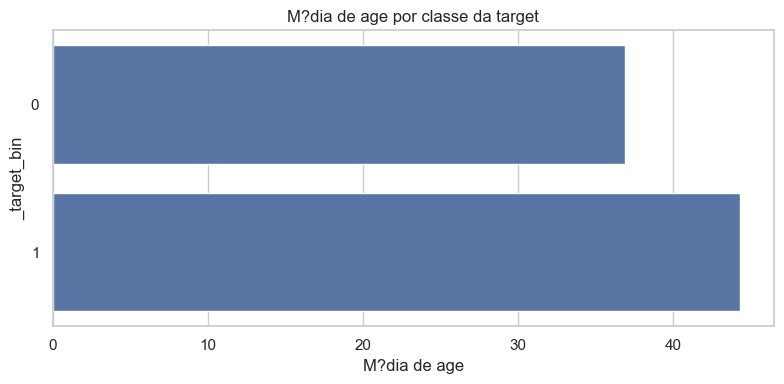

In [17]:
# Correlação de age com a target (point-biserial + distribuição por classe)
corr, p = pointbiserialr(df['_target_bin'], df['age'])
print(f"Point-biserial: {corr:.3f} | p-value: {p:.4g}")
hist_by_class_num('age', bins=30)


Point-biserial: 0.228 | p-value: 0


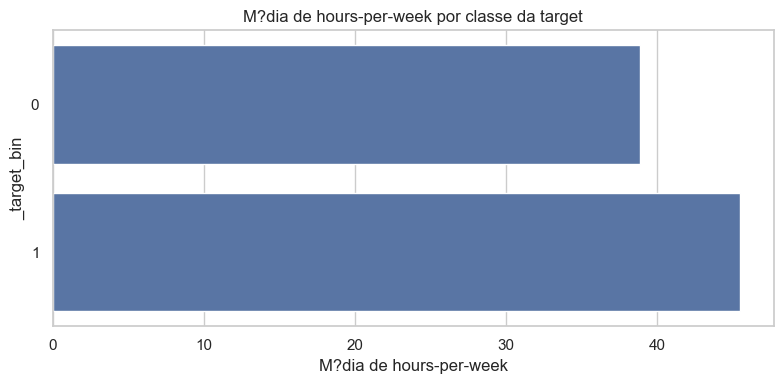

In [18]:
# Correlação de hours-per-week com a target (point-biserial + distribuição por classe)
corr, p = pointbiserialr(df['_target_bin'], df['hours-per-week'])
print(f"Point-biserial: {corr:.3f} | p-value: {p:.4g}")
hist_by_class_num('hours-per-week', bins=30)


In [ ]:
# Distribui??o de marital-status
plt.figure(figsize=(20, 2))
sns.set_theme(style='ticks')
sns.countplot(y='marital-status', data=df_cat)
plt.tight_layout()
plt.show()


count    48842.000000
mean       991.565313
std       7475.549906
min      -4356.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-balance, dtype: float64


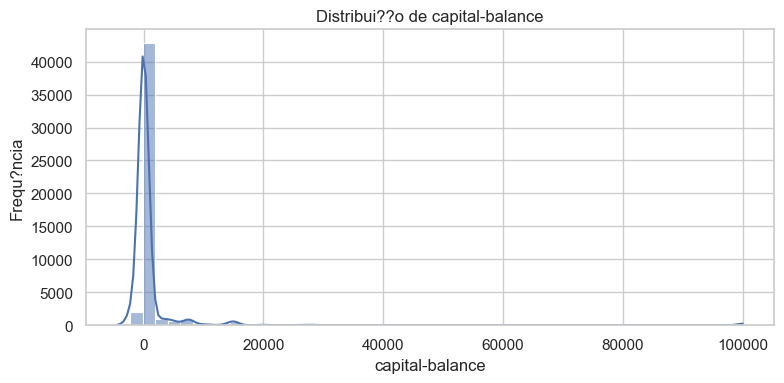

In [26]:
# Distribuição de capital-balance (com cap em 20k+)
print(df['capital-balance'].describe())
cb_clip = df['capital-balance'].clip(upper=20000)
plt.figure(figsize=(8, 4))
sns.histplot(cb_clip, bins=50, kde=True)
plt.title('Distribuição de capital-balance (20k+ agrupado)')
plt.xlabel('capital-balance (valores > 20k em 20k+)')
plt.ylabel('Frequência')
plt.xlim(cb_clip.min(), 20000)
plt.tight_layout()
plt.show()


Point-biserial: 0.214 | p-value: 0


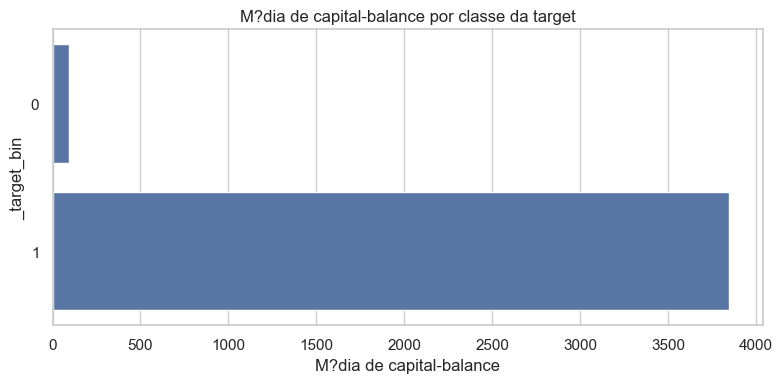

In [27]:
# Correlação de capital-balance com a target (point-biserial + distribuição por classe)
corr, p = pointbiserialr(df['_target_bin'], df['capital-balance'])
print(f"Point-biserial: {corr:.3f} | p-value: {p:.4g}")

cb_clip = df['capital-balance'].clip(upper=20000)
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df.assign(capital_balance_clip=cb_clip),
    x='capital_balance_clip',
    hue='_target_bin',
    bins=50,
    kde=False,
    stat='density',
    common_norm=False,
    alpha=0.5,
)
plt.title('Distribuição de capital-balance por classe (20k+ agrupado)')
plt.xlabel('capital-balance (valores > 20k em 20k+)')
plt.ylabel('Densidade')
plt.xlim(cb_clip.min(), 20000)
plt.tight_layout()
plt.show()


In [ ]:
# Heatmap: relationship por marital-status (normalizado por linha)
ct = pd.crosstab(df_cat['marital-status'], df_cat['relationship'])
ct_norm = ct.div(ct.sum(axis=1), axis=0)
plt.figure(figsize=(10, 5))
sns.heatmap(ct_norm, cmap='Blues')
plt.title('relationship por marital-status (normalizado por linha)')
plt.xlabel('relationship')
plt.ylabel('marital-status')
plt.tight_layout()
plt.show()


In [19]:
print('### Classificação das Variáveis ###
')

continuas_razao = []
discretas_ordinais = []
discretas_nominais = []

for feature in df.columns:
    if feature == '_target_bin':
        continue
    if feature in ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']:
        continuas_razao.append(feature)
    elif feature in ['education-num', 'education']:
        discretas_ordinais.append(feature)
    elif feature in ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']:
        discretas_nominais.append(feature)
    else:
        print(f"Warning: Feature '{feature}' not classified.")

print('Contínuas (Razão):')
for f in continuas_razao:
    print(f"- {f}")

print('
Discretas Ordinais:')
for f in discretas_ordinais:
    print(f"- {f}")

print('
Discretas Nominais:')
for f in discretas_nominais:
    print(f"- {f}")


### Classifica??o das Vari?veis ###

Cont?nuas (Raz?o):
- age
- fnlwgt
- capital-gain
- capital-loss
- hours-per-week

Discretas Ordinais:
- education
- education-num

Discretas Nominais:
- workclass
- marital-status
- occupation
- relationship
- race
- sex
- native-country


In [ ]:
# Workclass e escolaridade para pessoas com menos de 18 anos
u18 = df[df['age'] < 18]

plt.figure(figsize=(10, 4))
sns.countplot(data=u18, y='workclass')
plt.title('Workclass (idade < 18)')
plt.xlabel('Frequ?ncia')
plt.ylabel('workclass')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.countplot(data=u18, y='education')
plt.title('Escolaridade (idade < 18)')
plt.xlabel('Frequ?ncia')
plt.ylabel('education')
plt.tight_layout()
plt.show()
